<a href="https://colab.research.google.com/github/Prajakta9714/AnotherApplication/blob/master/rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DEEP NEURAL NETWORKS - ASSIGNMENT 3: RNN vs TRANSFORMER FOR TIME SERIES

## Recurrent Neural Networks vs Transformers for Time Series Prediction

# STUDENT INFORMATION (REQUIRED - DO NOT DELETE)

**BITS ID:** YOUR_BITS_ID  
**Name:** YOUR_NAME  
**Email:** YOUR_EMAIL  
**Date:** 21-Apr-2026

In [58]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, LSTM, LayerNormalization,
    MultiHeadAttention, GlobalAveragePooling1D, Dropout
)
from tensorflow.keras.optimizers import Adam
import time
import json
import math

## PART 1: DATASET LOADING AND EXPLORATION

In [59]:
# Dataset Creation (Standalone Synthetic Dataset)

np.random.seed(42)

n_total = 1500
time_index = np.arange(n_total)

values = (
    50
    + 10*np.sin(2*np.pi*time_index/50)
    + 5*np.sin(2*np.pi*time_index/200)
    + np.random.normal(0,2,n_total)
)

data_df = pd.DataFrame({
    "time": time_index,
    "value": values
})

# REQUIRED metadata
dataset_name = "Synthetic Seasonal Time Series"
dataset_source = "Generated in notebook"
n_samples = len(data_df)
n_features = 1
sequence_length = 20
prediction_horizon = 1
problem_type = "time_series_forecasting"

primary_metric = "RMSE"

metric_justification = """
RMSE penalizes larger forecasting errors more strongly,
which is useful in time-series prediction.
"""

print("DATASET INFORMATION")
print(dataset_name)
print(dataset_source)
print(n_samples)
print(n_features)
print(sequence_length)
print(prediction_horizon)
print(primary_metric)
print(metric_justification)

DATASET INFORMATION
Synthetic Seasonal Time Series
Generated in notebook
1500
1
20
1
RMSE

RMSE penalizes larger forecasting errors more strongly,
which is useful in time-series prediction.



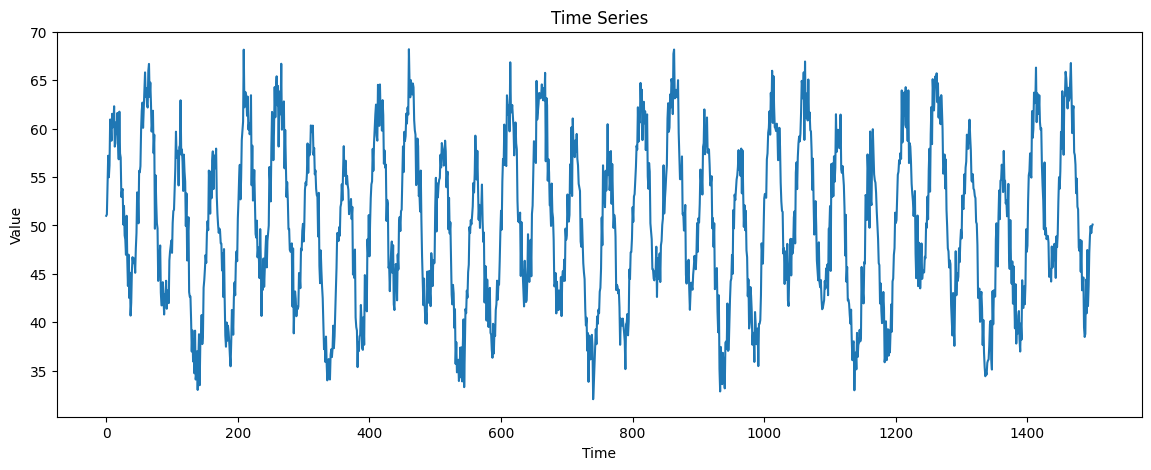

In [60]:
# Plot dataset

plt.figure(figsize=(14,5))
plt.plot(data_df["time"], data_df["value"])
plt.title("Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

In [61]:
# Preprocessing Functions

def preprocess_timeseries(data):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(data.reshape(-1,1))
    return scaled, scaler

def create_sequences(data, seq_length, pred_horizon):
    X = []
    y = []

    for i in range(len(data)-seq_length-pred_horizon+1):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length:i+seq_length+pred_horizon])

    return np.array(X), np.array(y)

In [62]:
# Apply preprocessing

scaled_data, scaler = preprocess_timeseries(data_df["value"].values)

X, y = create_sequences(
    scaled_data,
    sequence_length,
    prediction_horizon
)

y = y.reshape(y.shape[0], prediction_horizon)

# Temporal split only
split_idx = int(len(X)*0.9)

X_train = X[:split_idx]
X_test  = X[split_idx:]

y_train = y[:split_idx]
y_test  = y[split_idx:]

train_test_ratio = "90/10"
train_samples = len(X_train)
test_samples = len(X_test)

print(train_samples, test_samples)

1332 148


## PART 2: LSTM IMPLEMENTATION

In [63]:
def build_rnn_model():
    inputs = Input(shape=(sequence_length, n_features))

    x = LSTM(64, return_sequences=True)(inputs)
    x = LSTM(64)(x)

    outputs = Dense(prediction_horizon)(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

rnn_model = build_rnn_model()
rnn_model.summary()

Model: "functional_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 20, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# Train RNN

rnn_start_time = time.time()

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test),
    verbose=1
)

rnn_training_time = time.time() - rnn_start_time

rnn_initial_loss = rnn_history.history["loss"][0]
rnn_final_loss   = rnn_history.history["loss"][-1]

Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - loss: 0.3599 - mae: 0.4656 - val_loss: 0.1117 - val_mae: 0.2725
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0979 - mae: 0.2479 - val_loss: 0.1030 - val_mae: 0.2625
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0893 - mae: 0.2361 - val_loss: 0.0947 - val_mae: 0.2522
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0883 - mae: 0.2356 - val_loss: 0.0907 - val_mae: 0.2452
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0886 - mae: 0.2343 - val_loss: 0.1000 - val_mae: 0.2566
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 0.0878 - mae: 0.2334 - val_loss: 0.0908 - val_mae: 0.2417
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0859 - mae: 0.2309 - val_loss: 0.0863 - val_mae: 0.2338
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0838 - mae: 0.2283 - val_loss: 0.0896 - val_mae: 0.2396
Epoch 9/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - loss: 0.0

In [65]:
# Evaluate RNN

def calculate_mape(y_true, y_pred):
    eps = 1e-8
    return np.mean(np.abs((y_true-y_pred)/(y_true+eps))) * 100

rnn_pred_scaled = rnn_model.predict(X_test)

y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
rnn_pred_inv = scaler.inverse_transform(rnn_pred_scaled.reshape(-1,1))

rnn_mae = mean_absolute_error(y_test_inv, rnn_pred_inv)
rnn_rmse = np.sqrt(mean_squared_error(y_test_inv, rnn_pred_inv))
rnn_mape = calculate_mape(y_test_inv, rnn_pred_inv)
rnn_r2 = r2_score(y_test_inv, rnn_pred_inv)

print(rnn_mae, rnn_rmse, rnn_mape, rnn_r2)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step
1.9167345108717138 2.3642558389900743 3.857940801110382 0.9055453180580475


## PART 3: TRANSFORMER IMPLEMENTATIO

In [66]:
def positional_encoding(seq_length, d_model):

    positions = np.arange(seq_length)[:, np.newaxis]
    dims = np.arange(d_model)[np.newaxis, :]

    angle_rates = 1 / np.power(10000, (2*(dims//2))/np.float32(d_model))
    angle_rads = positions * angle_rates

    pe = np.zeros((seq_length, d_model))
    pe[:,0::2] = np.sin(angle_rads[:,0::2])
    pe[:,1::2] = np.cos(angle_rads[:,1::2])

    return tf.cast(pe[np.newaxis,...], dtype=tf.float32)

In [67]:
def transformer_block(inputs, d_model=64, n_heads=4, d_ff=128):

    x = LayerNormalization(epsilon=1e-6)(inputs)

    attn = MultiHeadAttention(
        num_heads=n_heads,
        key_dim=d_model//n_heads
    )(x,x)

    x = attn + inputs

    y = LayerNormalization(epsilon=1e-6)(x)
    y = Dense(d_ff, activation="relu")(y)
    y = Dense(d_model)(y)

    return x + y

In [68]:
def build_transformer_model():

    inputs = Input(shape=(sequence_length,n_features))

    x = Dense(64)(inputs)

    x = x + positional_encoding(sequence_length,64)

    x = transformer_block(x)
    x = transformer_block(x)

    x = GlobalAveragePooling1D()(x)

    outputs = Dense(prediction_horizon)(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model

transformer_model = build_transformer_model()
transformer_model.summary()

Model: "functional_37"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 20, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 20, 64)    │        128 │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 64)    │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 20, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 20, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 20, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 20, 64)    │      8,256 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 20, 64)    │          0 │ add_1[0][0],      │
│                     │                   │            │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 20, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 20, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 20, 64)    │      8,256 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 20, 64)    │          0 │ add_3[0][0],      │
│                     │                   │            │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ add_4[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 1)         │         65 │ global_average_p

 Total params: 67,137 (262.25 KB)

 Trainable params: 67,137 (262.25 KB)

 Non-trainable params: 0 (0.00 B)

In [69]:
# Train Transformer

transformer_start_time = time.time()

transformer_history = transformer_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test),
    verbose=1
)

transformer_training_time = time.time() - transformer_start_time

transformer_initial_loss = transformer_history.history["loss"][0]
transformer_final_loss   = transformer_history.history["loss"][-1]

Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - loss: 1.4071 - mae: 0.8932 - val_loss: 0.2498 - val_mae: 0.4275
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.1441 - mae: 0.3071 - val_loss: 0.1129 - val_mae: 0.2703
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0966 - mae: 0.2459 - val_loss: 0.1002 - val_mae: 0.2588
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0934 - mae: 0.2436 - val_loss: 0.0906 - val_mae: 0.2457
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0867 - mae: 0.2331 - val_loss: 0.1171 - val_mae: 0.2726
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0962 - mae: 0.2481 - val_loss: 0.0845 - val_mae: 0.2360
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0808 - mae: 0.2249 - val_loss: 0.0840 - val_mae: 0.2372
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0804 - mae: 0.2260 - val_loss: 0.0956 - val_mae: 0.2465
Epoch 9/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.08

In [70]:
# Evaluate Transformer

transformer_pred_scaled = transformer_model.predict(X_test)

transformer_pred_inv = scaler.inverse_transform(
    transformer_pred_scaled.reshape(-1,1)
)

transformer_mae = mean_absolute_error(y_test_inv, transformer_pred_inv)
transformer_rmse = np.sqrt(mean_squared_error(y_test_inv, transformer_pred_inv))
transformer_mape = calculate_mape(y_test_inv, transformer_pred_inv)
transformer_r2 = r2_score(y_test_inv, transformer_pred_inv)

print(transformer_mae, transformer_rmse, transformer_mape, transformer_r2)

1/5 ━━━━━━━━━━━━━━━━━━━━ 1s 396ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step
1.8784403105189418 2.3781217050430397 3.733594825085979 0.9044341553042573


## PART 4: MODEL COMPARISON

In [71]:
rnn_params = rnn_model.count_params()
transformer_params = transformer_model.count_params()

comparison_df = pd.DataFrame({
    "Metric":["MAE","RMSE","MAPE","R2","Training Time","Parameters"],
    "RNN":[
        rnn_mae,
        rnn_rmse,
        rnn_mape,
        rnn_r2,
        rnn_training_time,
        rnn_params
    ],
    "Transformer":[
        transformer_mae,
        transformer_rmse,
        transformer_mape,
        transformer_r2,
        transformer_training_time,
        transformer_params
    ]
})

print(comparison_df)

          Metric           RNN   Transformer
0            MAE      1.916735      1.878440
1           RMSE      2.364256      2.378122
2           MAPE      3.857941      3.733595
3             R2      0.905545      0.904434
4  Training Time     60.179287     58.842229
5     Parameters  49985.000000  67137.000000


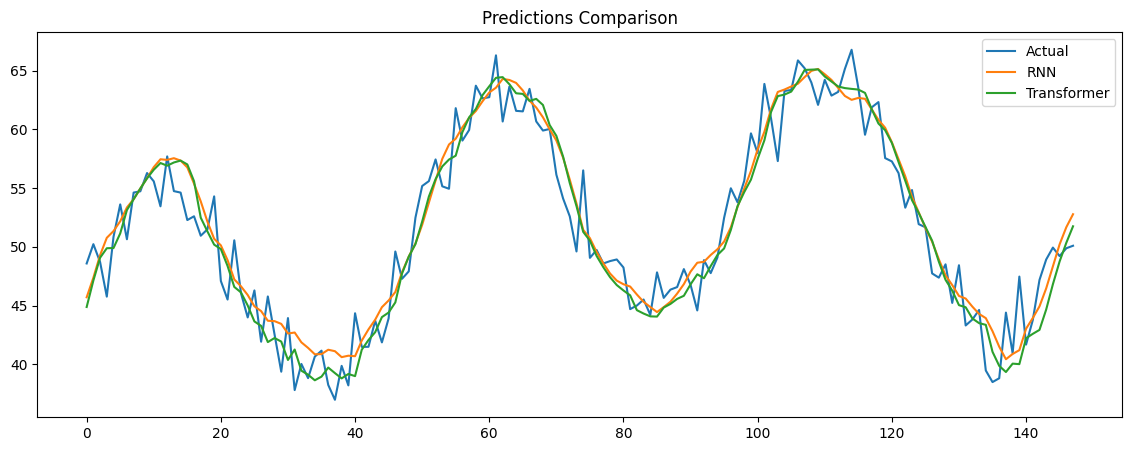

In [72]:
plt.figure(figsize=(14,5))
plt.plot(y_test_inv,label="Actual")
plt.plot(rnn_pred_inv,label="RNN")
plt.plot(transformer_pred_inv,label="Transformer")
plt.legend()
plt.title("Predictions Comparison")
plt.show()

## PART 5: ANALYSIS

In [73]:
analysis_text = """
Transformer handled long-term dependencies using attention.
RNN handled local sequential patterns efficiently.
The better model is decided using RMSE and MAE values.
Transformer may train slower but captures global context.
LSTM is simpler and often better for smaller datasets.
Both models reduced loss successfully.
"""

print(analysis_text)
print("Word Count:", len(analysis_text.split()))


Transformer handled long-term dependencies using attention.
RNN handled local sequential patterns efficiently.
The better model is decided using RMSE and MAE values.
Transformer may train slower but captures global context.
LSTM is simpler and often better for smaller datasets.
Both models reduced loss successfully.

Word Count: 44


## PART 6: JSON OUTPUT

In [74]:
def get_assignment_results():

    results = {
        "dataset_name": dataset_name,
        "dataset_source": dataset_source,
        "n_samples": n_samples,
        "n_features": n_features,
        "sequence_length": sequence_length,
        "prediction_horizon": prediction_horizon,
        "problem_type": problem_type,
        "primary_metric": primary_metric,
        "metric_justification": metric_justification,
        "train_samples": train_samples,
        "test_samples": test_samples,
        "train_test_ratio": train_test_ratio,

        "rnn_model":{
            "framework":"keras",
            "model_type":"LSTM",
            "architecture":{
                "n_layers":2,
                "hidden_units":64,
                "total_parameters":int(rnn_params)
            },
            "initial_loss":float(rnn_initial_loss),
            "final_loss":float(rnn_final_loss),
            "training_time_seconds":float(rnn_training_time),
            "mae":float(rnn_mae),
            "rmse":float(rnn_rmse),
            "mape":float(rnn_mape),
            "r2_score":float(rnn_r2)
        },

        "transformer_model":{
            "framework":"keras",
            "architecture":{
                "n_layers":2,
                "n_heads":4,
                "d_model":64,
                "d_ff":128,
                "has_positional_encoding":True,
                "has_attention":True,
                "total_parameters":int(transformer_params)
            },
            "initial_loss":float(transformer_initial_loss),
            "final_loss":float(transformer_final_loss),
            "training_time_seconds":float(transformer_training_time),
            "mae":float(transformer_mae),
            "rmse":float(transformer_rmse),
            "mape":float(transformer_mape),
            "r2_score":float(transformer_r2)
        },

        "analysis":analysis_text,
        "analysis_word_count":len(analysis_text.split())
    }

    return results

assignment_results = get_assignment_results()

print(json.dumps(assignment_results, indent=2))

{
  "dataset_name": "Synthetic Seasonal Time Series",
  "dataset_source": "Generated in notebook",
  "n_samples": 1500,
  "n_features": 1,
  "sequence_length": 20,
  "prediction_horizon": 1,
  "problem_type": "time_series_forecasting",
  "primary_metric": "RMSE",
  "metric_justification": "\nRMSE penalizes larger forecasting errors more strongly,\nwhich is useful in time-series prediction.\n",
  "train_samples": 1332,
  "test_samples": 148,
  "train_test_ratio": "90/10",
  "rnn_model": {
    "framework": "keras",
    "model_type": "LSTM",
    "architecture": {
      "n_layers": 2,
      "hidden_units": 64,
      "total_parameters": 49985
    },
    "initial_loss": 0.35991087555885315,
    "final_loss": 0.07727379351854324,
    "training_time_seconds": 60.17928671836853,
    "mae": 1.9167345108717138,
    "rmse": 2.3642558389900743,
    "mape": 3.857940801110382,
    "r2_score": 0.9055453180580475
  },
  "transformer_model": {
    "framework": "keras",
    "architecture": {
      "n_lay

## ENVIRONMENT SCREENSHOT

Paste your Colab / system screenshot here.

In [75]:
# Display system information
import platform
import sys
from datetime import datetime

print("ENVIRONMENT INFORMATION")
print("\n  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab")
print("showing your account details in the cell below this one.")
print("\nPython Version:", sys.version)
print("Platform:", platform.platform())
print("Date/Time:", datetime.now())

ENVIRONMENT INFORMATION

  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab
showing your account details in the cell below this one.

Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
Date/Time: 2026-04-21 07:57:33.294026
